# EDA: Correlation Analysis

Exploring relationships between key numeric features — Overall, Potential, Wage, Value, and Age

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")
print(df[['Name', 'Overall', 'Potential', 'Age', 'Wage', 'Value']].head())

Data loaded: 17660 players
              Name  Overall  Potential  Age   Wage    Value
0      L. Goretzka       87         88   27  €115K     €91M
1  Bruno Fernandes       86         87   27  €190K   €78.5M
2         M. Acuña       85         85   30   €46K   €46.5M
3     K. De Bruyne       91         91   31  €350K  €107.5M
4       N. Barella       86         89   25  €110K   €89.5M


In [2]:
# Parse currency columns
def parse_currency(val):
    """Convert currency strings like '€115K' to numeric values"""
    if pd.isna(val) or val == '':
        return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val) if val else np.nan

df['wage_numeric'] = df['Wage'].apply(parse_currency)
df['value_numeric'] = df['Value'].apply(parse_currency)

# Keep only usable rows
df_clean = df[
    (df['Overall'] >= 50) &
    df['wage_numeric'].notna() &
    df['value_numeric'].notna()
].copy()

# Log-transform skewed financial columns for better correlation
df_clean['log_wage']  = np.log1p(df_clean['wage_numeric'])
df_clean['log_value'] = np.log1p(df_clean['value_numeric'])

print(f"Clean dataset: {df_clean.shape[0]} players")

Clean dataset: 17307 players


Correlation Matrix:
           Overall  Potential    Age  Log Wage  Log Value
Overall      1.000      0.688  0.595     0.617      0.492
Potential    0.688      1.000 -0.052     0.471      0.477
Age          0.595     -0.052  1.000     0.296      0.063
Log Wage     0.617      0.471  0.296     1.000      0.816
Log Value    0.492      0.477  0.063     0.816      1.000


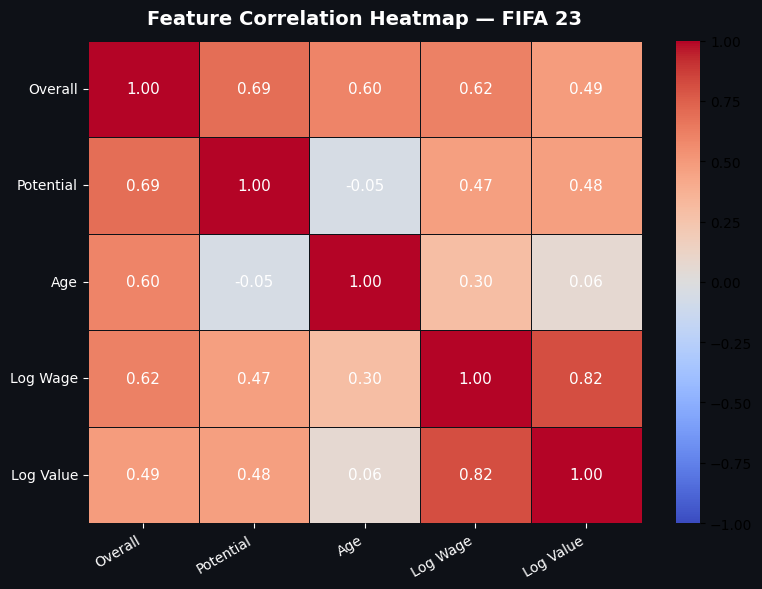


Key Insights:
  Overall  ↔ Log Wage  : 0.617
  Overall  ↔ Log Value : 0.492
  Log Wage ↔ Log Value : 0.816
  Age      ↔ Overall   : 0.595
  Age      ↔ Potential : -0.052


In [3]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────
corr_cols = {
    'Overall':    df_clean['Overall'],
    'Potential':  df_clean['Potential'],
    'Age':        df_clean['Age'],
    'Log Wage':   df_clean['log_wage'],
    'Log Value':  df_clean['log_value'],
}
corr_df = pd.DataFrame(corr_cols)
corr_matrix = corr_df.corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#1a1d27')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#0e1117',
    ax=ax,
    annot_kws={'size': 11, 'color': 'white'}
)

ax.set_title('Feature Correlation Heatmap — FIFA 23', color='white', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors='white')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  Overall  ↔ Log Wage  : {corr_matrix.loc['Overall','Log Wage']:.3f}")
print(f"  Overall  ↔ Log Value : {corr_matrix.loc['Overall','Log Value']:.3f}")
print(f"  Log Wage ↔ Log Value : {corr_matrix.loc['Log Wage','Log Value']:.3f}")
print(f"  Age      ↔ Overall   : {corr_matrix.loc['Age','Overall']:.3f}")
print(f"  Age      ↔ Potential : {corr_matrix.loc['Age','Potential']:.3f}")

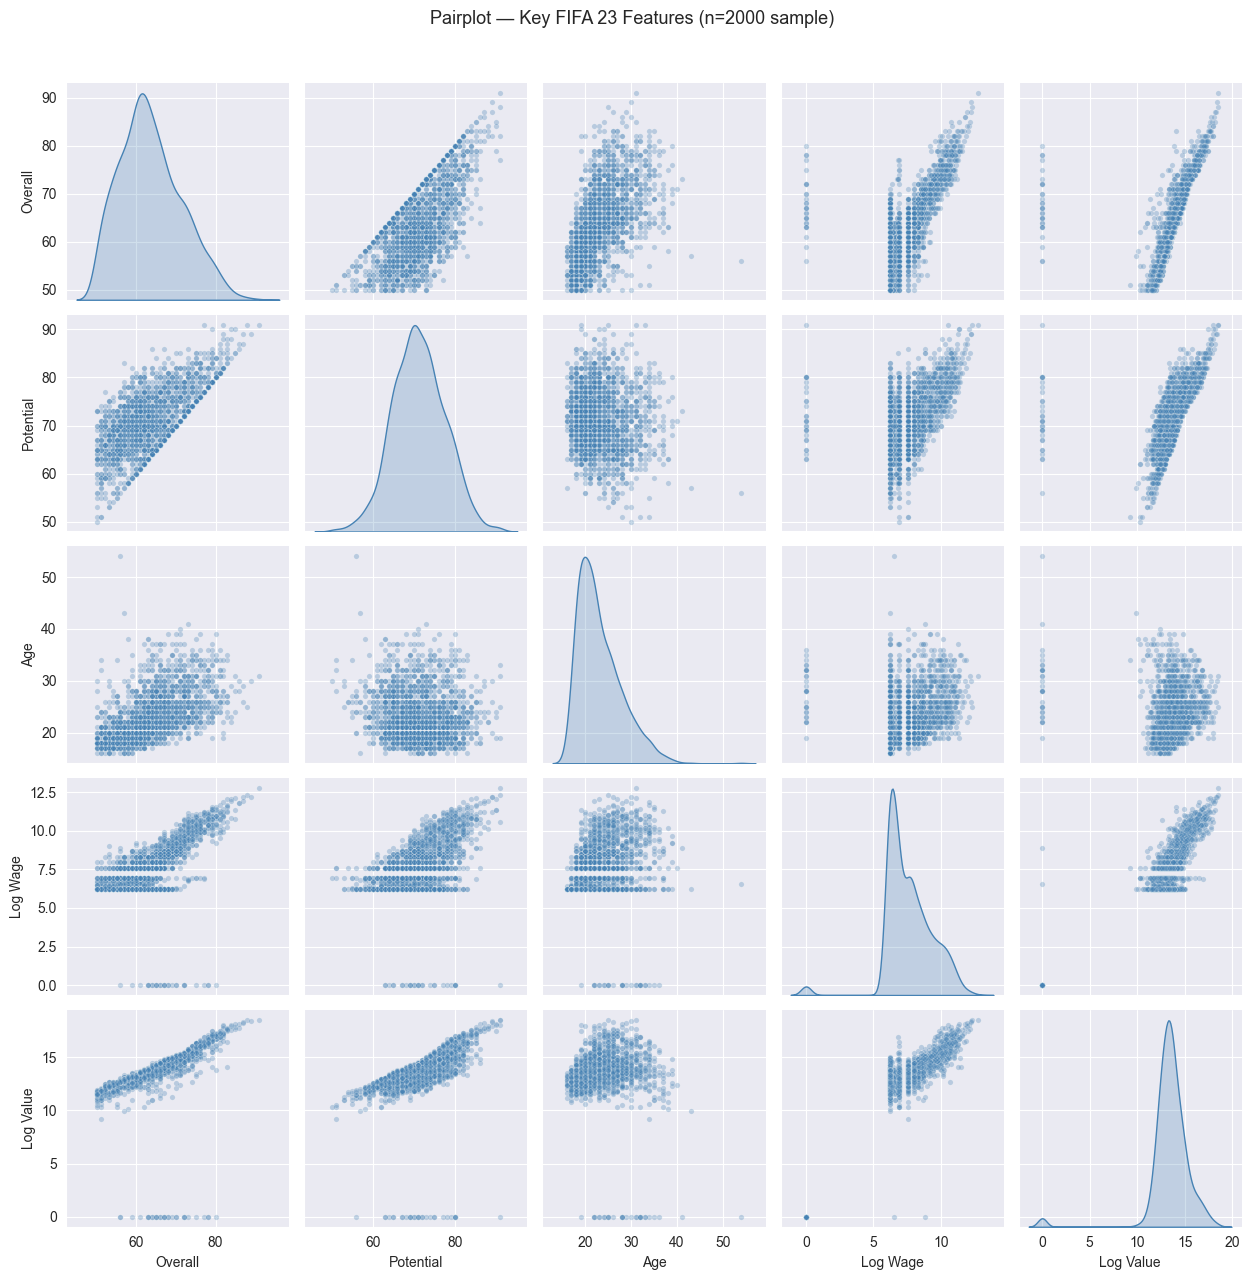

In [4]:
# ── Pairplot: scatter matrix of all key features ─────────────────────────────
# Sample for speed (pairplot on 17k rows is slow)
sample = df_clean.sample(n=2000, random_state=42)

pair_data = sample[['Overall', 'Potential', 'Age', 'log_wage', 'log_value']].rename(columns={
    'log_wage': 'Log Wage', 'log_value': 'Log Value'
})

sns.set_style('darkgrid')
g = sns.pairplot(
    pair_data,
    diag_kind='kde',
    plot_kws=dict(alpha=0.3, s=15, color='steelblue'),
    diag_kws=dict(color='steelblue', fill=True)
)
g.fig.suptitle('Pairplot — Key FIFA 23 Features (n=2000 sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# ── Age vs Overall — Peak Age Curve ──────────────────────────────────────────
age_stats = df_clean.groupby('Age')['Overall'].agg(['mean', 'median', 'count']).reset_index()
age_stats = age_stats[age_stats['count'] >= 20]  # only ages with enough players

fig = go.Figure()

# Scatter: individual players (sampled)
sample2 = df_clean.sample(n=3000, random_state=1)
fig.add_trace(go.Scatter(
    x=sample2['Age'], y=sample2['Overall'],
    mode='markers',
    marker=dict(size=4, opacity=0.25, color='steelblue'),
    name='Players'
))

# Line: median overall per age
fig.add_trace(go.Scatter(
    x=age_stats['Age'], y=age_stats['median'],
    mode='lines+markers',
    line=dict(color='orange', width=3),
    marker=dict(size=6),
    name='Median Overall'
))

# Mark peak age
peak = age_stats.loc[age_stats['median'].idxmax()]
fig.add_annotation(
    x=peak['Age'], y=peak['median'] + 0.5,
    text=f"Peak: Age {int(peak['Age'])} ({peak['median']:.1f})",
    showarrow=True, arrowhead=2, arrowcolor='yellow',
    font=dict(color='yellow', size=12)
)

fig.update_layout(
    title='Age vs Overall Rating — When Do Players Peak?',
    xaxis_title='Age',
    yaxis_title='Overall Rating',
    template='plotly_dark',
    height=500,
    legend=dict(x=0.02, y=0.98)
)
fig.show()

print(f"\nPeak median rating at age {int(peak['Age'])}: {peak['median']:.1f}")
print("\nMedian Overall by Age:")
print(age_stats[['Age', 'median', 'count']].to_string(index=False))


Peak median rating at age 35: 73.0

Median Overall by Age:
 Age  median  count
  16    54.0    134
  17    55.0    649
  18    56.0   1378
  19    58.0   1863
  20    60.0   1911
  21    61.0   1826
  22    63.0   1655
  23    65.0   1228
  24    66.0   1084
  25    67.0    931
  26    68.0    801
  27    69.0    690
  28    69.0    607
  29    69.0    528
  30    70.0    475
  31    71.0    385
  32    71.0    313
  33    71.0    242
  34    72.0    207
  35    73.0    146
  36    71.5    104
  37    70.0     67
  38    72.0     28
  39    72.5     28


In [6]:
# ── Wage vs Value: Efficiency Scatter ────────────────────────────────────────
# Are high earners also high market value? Who is overpaid vs underpaid?
df_plot = df_clean.copy()
df_plot['wage_m'] = df_plot['wage_numeric'] / 1_000          # weekly wage in €K
df_plot['value_m'] = df_plot['value_numeric'] / 1_000_000    # value in €M

# Ratio: value per € of weekly wage
df_plot['efficiency'] = df_plot['value_m'] / (df_plot['wage_m'] + 1)

top_efficient    = df_plot.nlargest(10, 'efficiency')
bottom_efficient = df_plot.nsmallest(10, 'efficiency')

fig = px.scatter(
    df_plot.sample(3000, random_state=42),
    x='wage_m',
    y='value_m',
    color='Overall',
    color_continuous_scale='RdYlGn',
    hover_data=['Name', 'Club', 'Overall'],
    opacity=0.5,
    title='Weekly Wage (€K) vs Market Value (€M)',
    labels={'wage_m': 'Weekly Wage (€K)', 'value_m': 'Market Value (€M)'},
    template='plotly_dark'
)

fig.update_layout(height=520)
fig.show()

print("\n=== BEST VALUE PLAYERS (High Value, Low Wage) ===")
print(top_efficient[['Name', 'Club', 'Overall', 'wage_m', 'value_m', 'efficiency']].to_string(index=False))

print("\n=== WORST VALUE PLAYERS (Low Value, High Wage) ===")
print(bottom_efficient[['Name', 'Club', 'Overall', 'wage_m', 'value_m', 'efficiency']].to_string(index=False))


=== BEST VALUE PLAYERS (High Value, Low Wage) ===
         Name                      Club  Overall  wage_m  value_m  efficiency
 V. Tsygankov               Dynamo Kyiv       80    1.00     32.0   16.000000
M. Shaparenko               Dynamo Kyiv       77    1.00     23.5   11.750000
    D. Hancko           AC Sparta Praha       77    0.95     22.0   11.282051
 D. Livaković             Dinamo Zagreb       80    1.00     20.5   10.250000
    L. Suárez Club Nacional de Football       84    1.00     18.0    9.000000
   M. Solomon                    Fulham       76    0.90     17.0    8.947368
         Tetê        Olympique Lyonnais       76    1.00     17.0    8.500000
22 K. Manolas            Olympiacos CFP       82    2.00     25.0    8.333333
    L. Krejčí           AC Sparta Praha       76    0.90     15.5    8.157895
    J. Kuchta           AC Sparta Praha       77    1.00     14.0    7.000000

=== WORST VALUE PLAYERS (Low Value, High Wage) ===
             Name         Club  Overall